## MCNICHOLS STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

mcnichols=pd.read_csv('../stock_data/mcnichols.csv') ## so it can be small letter. This is cool.
mcnichols=mcnichols.drop(columns=['high_price','low_price'])
mcnichols.rename(columns={'trade_date':'date'},inplace=True)
mcnichols['date']=pd.to_datetime(mcnichols['date'])
mcnichols['month']=mcnichols['date'].dt.month
mcnichols['quarter']=mcnichols['date'].dt.quarter
mcnichols['year']=mcnichols['date'].dt.year

mcnichols

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42865,MCNICHOLS,2017-01-03,1.29,1.29,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43425,MCNICHOLS,2017-01-04,1.29,1.29,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43535,MCNICHOLS,2017-01-05,1.29,1.29,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43645,MCNICHOLS,2017-01-06,1.29,1.29,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43735,MCNICHOLS,2017-01-09,1.29,1.29,2850,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2255,298092,MCNICHOLS,2026-07-13,4.75,4.75,20262166,2026-07-13T15:10:02.995074+00:00,7,3,2026
2256,298530,MCNICHOLS,2026-07-14,4.60,4.60,13546792,2026-07-14T15:10:03.094441+00:00,7,3,2026
2257,298968,MCNICHOLS,2026-07-15,5.00,5.00,3971041,2026-07-15T15:10:03.078609+00:00,7,3,2026
2258,299406,MCNICHOLS,2026-07-16,5.40,5.40,4199997,2026-07-16T15:10:03.113936+00:00,7,3,2026


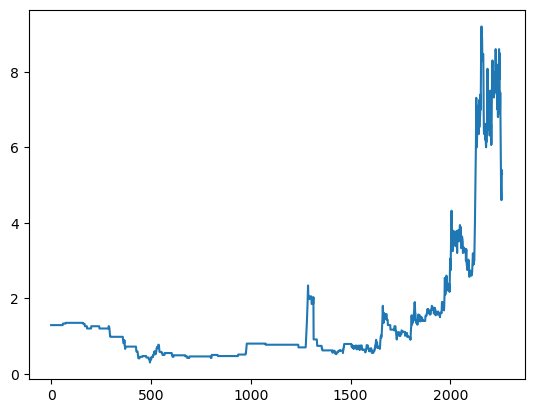

In [2]:
import matplotlib.pyplot as plt

plt.plot(mcnichols['close_price'])
plt.show()

In [3]:
mcnichols_end_month_df = (
    mcnichols
    .sort_values("date")
    .groupby(mcnichols["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

mcnichols_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45435,MCNICHOLS,2017-01-31,1.29,1.29,16000,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47258,MCNICHOLS,2017-02-28,1.29,1.29,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49374,MCNICHOLS,2017-03-31,1.33,1.33,1000,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51201,MCNICHOLS,2017-04-28,1.35,1.35,20,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53124,MCNICHOLS,2017-05-31,1.35,1.35,50,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35329,MCNICHOLS,2026-03-31,7.31,7.31,2599554,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281155,MCNICHOLS,2026-04-30,6.72,6.72,1637984,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284221,MCNICHOLS,2026-05-29,7.93,7.93,1591741,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294149,MCNICHOLS,2026-06-30,8.50,8.50,3461401,2026-06-30T15:10:03.08168+00:00,6,2,2026


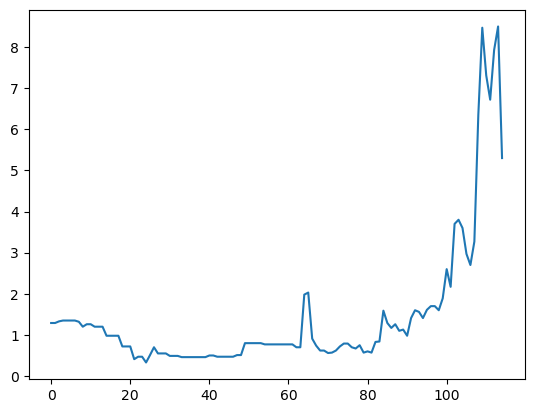

In [4]:
plt.plot(mcnichols_end_month_df['close_price'])
plt.show()

In [5]:
mcnichols_end_month_df['returns']=mcnichols_end_month_df['close_price'].pct_change()*100
mcnichols_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45435,MCNICHOLS,2017-01-31,1.29,1.29,16000,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47258,MCNICHOLS,2017-02-28,1.29,1.29,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49374,MCNICHOLS,2017-03-31,1.33,1.33,1000,2026-04-08T02:45:42.281198+00:00,3,1,2017,3.100775
3,51201,MCNICHOLS,2017-04-28,1.35,1.35,20,2026-04-08T02:51:55.619599+00:00,4,2,2017,1.503759
4,53124,MCNICHOLS,2017-05-31,1.35,1.35,50,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35329,MCNICHOLS,2026-03-31,7.31,7.31,2599554,2026-03-31T15:00:02.085058+00:00,3,1,2026,-13.695396
111,281155,MCNICHOLS,2026-04-30,6.72,6.72,1637984,2026-04-30T15:00:02.170664+00:00,4,2,2026,-8.071135
112,284221,MCNICHOLS,2026-05-29,7.93,7.93,1591741,2026-05-29T15:00:02.455558+00:00,5,2,2026,18.005952
113,294149,MCNICHOLS,2026-06-30,8.50,8.50,3461401,2026-06-30T15:10:03.08168+00:00,6,2,2026,7.187894


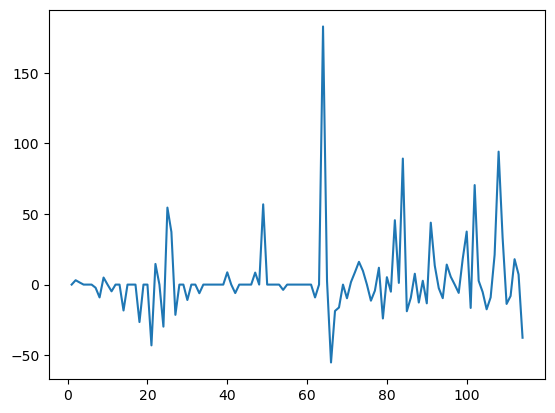

In [6]:
plt.plot(mcnichols_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(mcnichols_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-8.575927312911379, 7.963709402508292e-14, 1, 112, {'1%': -3.4901313156261384, '5%': -2.8877122815688776, '10%': -2.5807296460459184}, 957.735137598414)
stationary


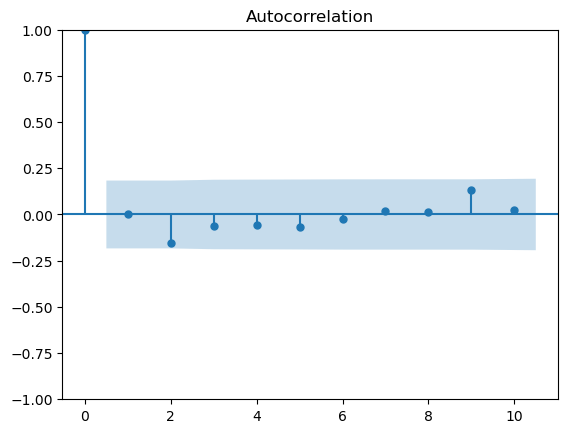

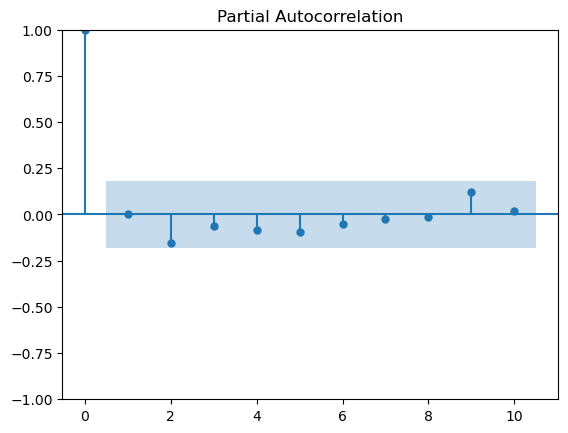

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(mcnichols_end_month_df['returns'].dropna(), lags=10)
plot_pacf(mcnichols_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=mcnichols_end_month_df['close_price'][:-10]
test=mcnichols_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -7.631104551223562]
[0, 0, 0, 0, 0, 1, -5.392590418061247]
[0, 0, 0, 0, 0, 2, -3.9306831419864396]
[0, 0, 0, 0, 1, 0, -3.326122339605149]
[0, 0, 0, 0, 1, 1, -3.0583083418362165]
[0, 0, 0, 0, 1, 2, -3.329181851750776]
[0, 0, 0, 0, 2, 0, -2.2733293181371486]
[0, 0, 0, 0, 2, 1, -2.505255906752808]
[0, 0, 0, 0, 2, 2, -2.51472500516567]
[0, 0, 0, 1, 0, 0, -3.605129706440457]
[0, 0, 0, 1, 0, 1, -3.3692062671862955]
[0, 0, 0, 1, 0, 2, -4.02664620877937]
[0, 0, 0, 1, 1, 0, -3.0875144963589154]
[0, 0, 0, 1, 1, 1, -3.1973147213925843]
[0, 0, 0, 1, 1, 2, -3.230817691906413]
[0, 0, 0, 1, 2, 0, -2.304614922618994]
[0, 0, 0, 1, 2, 1, -2.5028702874853157]
[0, 0, 0, 1, 2, 2, -2.5755963638567514]
[0, 0, 0, 2, 0, 0, -3.4442473104376408]
[0, 0, 0, 2, 0, 1, -3.5229755795589854]
[0, 0, 0, 2, 0, 2, -3.739936043276897]
[0, 0, 0, 2, 1, 0, -3.3432209293458284]
[0, 0, 0, 2, 1, 1, -3.3716326135854215]
[0, 0, 0, 2, 1, 2, -3.351549530858855]
[0, 0, 0, 2, 2, 0, -2.790642163523248]
[0, 0, 0, 2, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-8.712873
0,0,0,0,0,0,0,-7.631105
27,0,0,1,0,0,0,-7.446171
54,0,0,2,0,0,0,-7.420453
168,0,2,0,0,2,0,-6.711216
...,...,...,...,...,...,...,...
662,2,2,0,1,1,2,0.464213
671,2,2,0,2,1,2,0.468642
653,2,2,0,0,1,2,0.469498
661,2,2,0,1,1,1,0.471134


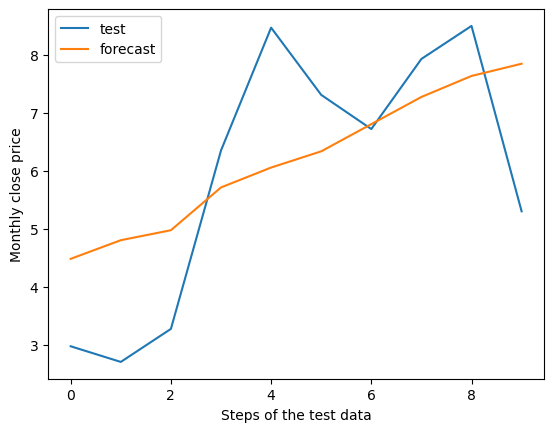

r2_score:  0.4732009294627221
rmse:  1.5638378515380535
description:  count    115.000000
mean       1.426609
std        1.660254
min        0.330000
25%        0.570000
50%        0.800000
75%        1.350000
max        8.500000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=mcnichols_end_month_df['close_price'][:-10]
y_test=mcnichols_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(2,1,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', mcnichols_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=mcnichols_end_month_df['returns'].dropna()[:-10]
test=mcnichols_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.06384841487550008]


[0, 0, 0, 0, 0, 1, -0.058721636630899576]
[0, 0, 0, 0, 0, 2, 0.022029540642884093]
[0, 0, 0, 0, 1, 0, -0.8709145635176556]
[0, 0, 0, 0, 1, 1, 0.1830554697861152]
[0, 0, 0, 0, 1, 2, 0.22052365718639133]
[0, 0, 0, 0, 2, 0, -5.480493237407289]
[0, 0, 0, 0, 2, 1, -1.0521191904387388]
[0, 0, 0, 0, 2, 2, 0.1898735910679441]
[0, 0, 0, 1, 0, 0, -0.053342681713056006]
[0, 0, 0, 1, 0, 1, 0.005508694883593956]
[0, 0, 0, 1, 0, 2, 0.045683062370453276]
[0, 0, 0, 1, 1, 0, 0.22128592857584295]
[0, 0, 0, 1, 1, 1, 0.23061156746315048]
[0, 0, 0, 1, 1, 2, 0.241592475754142]
[0, 0, 0, 1, 2, 0, -0.9653914465229607]
[0, 0, 0, 1, 2, 1, 0.08505404209628897]
[0, 0, 0, 1, 2, 2, 0.3366980405507999]
[0, 0, 0, 2, 0, 0, 0.021357921871353103]
[0, 0, 0, 2, 0, 1, 0.040946266420266]
[0, 0, 0, 2, 0, 2, 0.053774663166471615]
[0, 0, 0, 2, 1, 0, 0.2728956484605043]
[0, 0, 0, 2, 1, 1, 0.2506375359704237]
[0, 0, 0, 2, 1, 2, 0.25088112656735273]
[0, 0, 0, 2, 2, 0, -1.4345116516110892]
[0, 0, 0, 2, 2, 1, 0.17312803929689968]
[

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
618,2,1,1,2,2,2,-416048.446137
444,1,2,1,1,1,2,-147308.667109
168,0,2,0,0,2,0,-221.732802
409,1,2,0,0,2,0,-64.947091
410,1,2,0,0,2,1,-57.671902
...,...,...,...,...,...,...,...
125,0,1,1,1,2,2,0.347856
393,1,1,2,1,2,2,0.348347
206,0,2,1,1,2,2,0.368903
71,0,0,2,1,2,2,0.393465


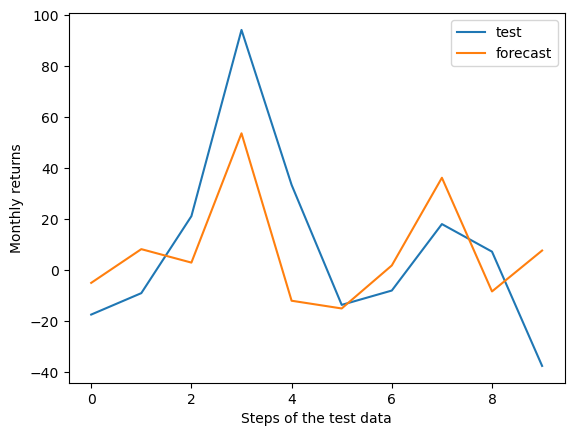

r2_score:  0.40305527506754824
rmse:  26.869632452634484
description:  count    114.000000
mean       3.860352
std       27.059880
min      -55.172414
25%       -5.197368
50%        0.000000
75%        3.007400
max      182.857143
Name: returns, dtype: float64


In [15]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=mcnichols_end_month_df['returns'].dropna()[:-10]
y_test=mcnichols_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,1), 
seasonal_order=(2,2,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', mcnichols_end_month_df.returns.dropna().describe())

Very good. We will work with the returns
